In [1]:
from PIL import Image, ImageDraw
import csv
import io
from IPython.display import display, Image as IPyImage

In [2]:
def draw_bounding_boxes_and_display(image_path, csv_data):
    """
    レントゲン画像内の腫瘍の位置に枠線を描画し、Jupyter Lab 上に表示します。

    Args:
        image_path (str): 画像ファイルのパス。
        csv_data (str): 腫瘍の位置情報を含む CSV 形式の文字列。
    """
    try:
        img = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(img)

        reader = csv.DictReader(csv_data.splitlines())
        for row in reader:
            if row['patientId'] == '00436515-870c-4b36-a041-de91049b9ab4' and row['Target'] == '1':
                x = float(row['x'])
                y = float(row['y'])
                width = float(row['width'])
                height = float(row['height'])
                bbox = (x, y, x + width, y + height)
                draw.rectangle(bbox, outline='red', width=3)

        # Pillow Image オブジェクトを BytesIO オブジェクトに保存
        buffered = io.BytesIO()
        img.save(buffered, format="PNG")
        img_bytes = buffered.getvalue()

        # Jupyter Lab 上に画像を表示
        display(IPyImage(data=img_bytes))

        # 必要であれば画像を保存
        # output_path = image_path.replace(".png", "_bbox.png")
        # img.save(output_path)
        # print(f"枠線が描画された画像は {output_path} に保存されました。")

    except FileNotFoundError:
        print(f"エラー: 画像ファイル {image_path} が見つかりません。")
    except Exception as e:
        print(f"予期せぬエラーが発生しました: {e}")

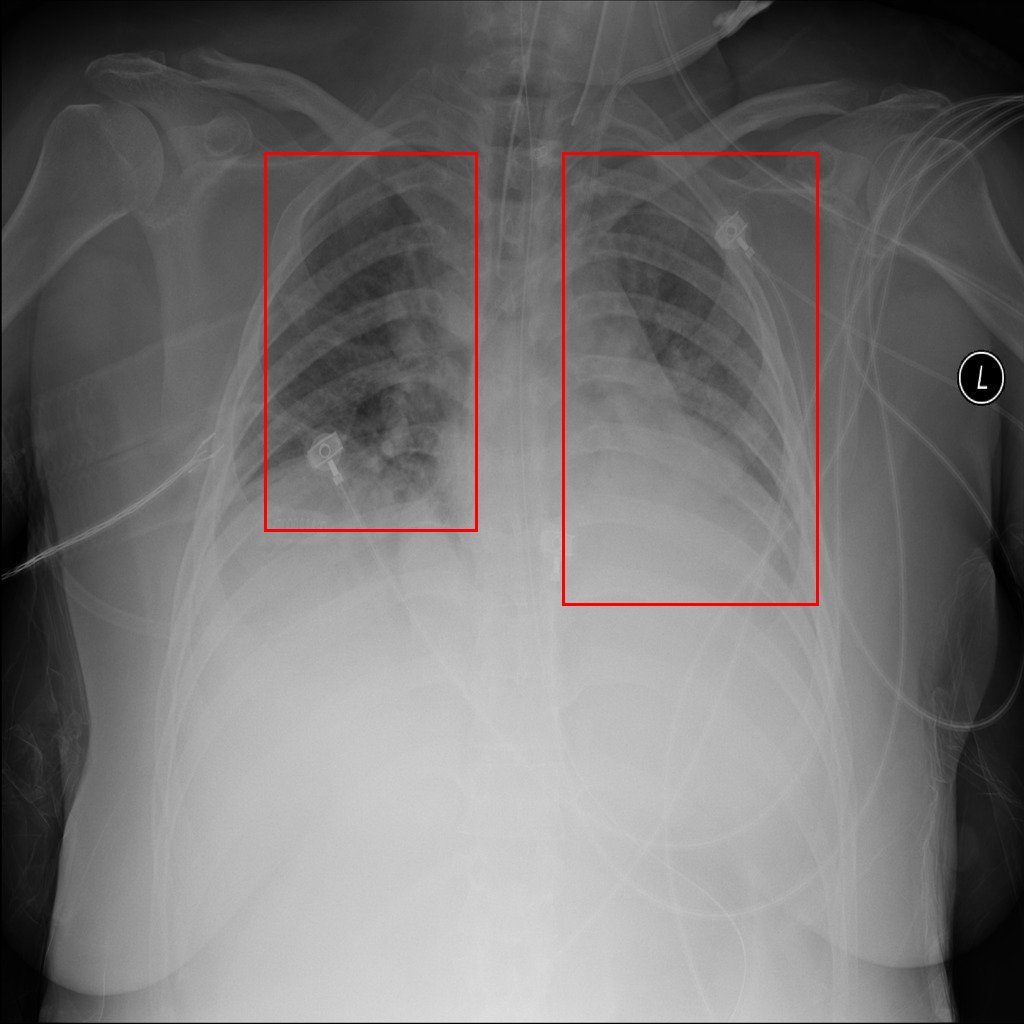

In [3]:
# 画像ファイルのパスとCSVデータを指定
image_file = '../../datasets/rsna-pneumonia-detection-challenge/train_png/00436515-870c-4b36-a041-de91049b9ab4.png'
csv_data = """patientId,x,y,width,height,Target
00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1
"""

# 枠線を描画して表示する関数を実行
draw_bounding_boxes_and_display(image_file, csv_data)

In [4]:
import pandas as pd

In [5]:
def draw_bounding_boxes_and_display(image_path, df):
    """
    レントゲン画像内の腫瘍の位置に枠線を描画し、Jupyter Lab 上に表示します。
    pandas DataFrame から腫瘍の位置情報を取得します。

    Args:
        image_path (str): 画像ファイルのパス。
        df (pd.DataFrame): 腫瘍の位置情報を含む pandas DataFrame。
    """
    try:
        img = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(img)

        target_boxes = df[(df['patientId'] == '00436515-870c-4b36-a041-de91049b9ab4') & (df['Target'] == 1)]

        for index, row in target_boxes.iterrows():
            x = float(row['x'])
            y = float(row['y'])
            width = float(row['width'])
            height = float(row['height'])
            bbox = (x, y, x + width, y + height)
            draw.rectangle(bbox, outline='red', width=3)

        # Pillow Image オブジェクトを BytesIO オブジェクトに保存
        buffered = io.BytesIO()
        img.save(buffered, format="PNG")
        img_bytes = buffered.getvalue()

        # Jupyter Lab 上に画像を表示
        display(IPyImage(data=img_bytes))

        # 必要であれば画像を保存
        # output_path = image_path.replace(".png", "_bbox.png")
        # img.save(output_path)
        # print(f"枠線が描画された画像は {output_path} に保存されました。")

    except FileNotFoundError:
        print(f"エラー: 画像ファイル {image_path} が見つかりません。")
    except Exception as e:
        print(f"予期せぬエラーが発生しました: {e}")

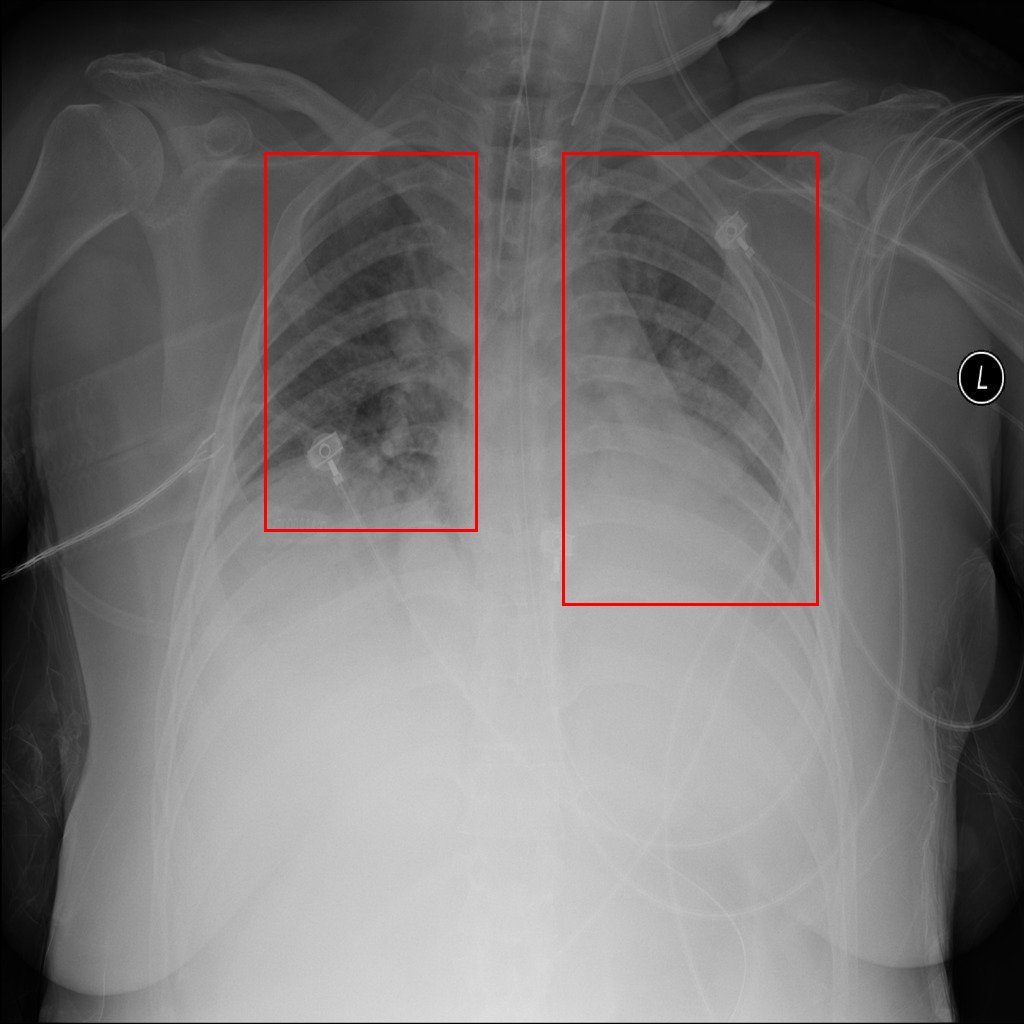

In [9]:
# CSV ファイルのパスと画像ファイルのパスを指定
csv_file = '../../datasets/rsna-pneumonia-detection-challenge/train.csv'  # 実際の CSV ファイル名に合わせてください
image_file = '../../datasets/rsna-pneumonia-detection-challenge/train_png/00436515-870c-4b36-a041-de91049b9ab4.png'

# pandas を使用して CSV ファイルを読み込む
try:
    df = pd.read_csv(csv_file)
    # 枠線を描画して表示する関数を実行
    draw_bounding_boxes_and_display(image_file, df)
except FileNotFoundError:
    print(f"エラー: CSV ファイル {csv_file} が見つかりません。")
except Exception as e:
    print(f"CSV ファイルの読み込み中にエラーが発生しました: {e}")

In [10]:
from PIL import Image, ImageDraw
import pandas as pd
import io
from IPython.display import display, Image as IPyImage
import os

In [13]:
def draw_bounding_boxes_and_display(image_path, df):
    """
    レントゲン画像内の腫瘍の位置に枠線を描画し、Jupyter Lab 上に表示します。
    pandas DataFrame から腫瘍の位置情報を取得し、image_path に基づいてフィルタリングします。

    Args:
        image_path (str): 画像ファイルのパス。
        df (pd.DataFrame): 腫瘍の位置情報を含む pandas DataFrame。
    """
    try:
        img = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(img)

        # image_path から patientId を抽出 (拡張子を除去)
        patient_id_from_path = os.path.splitext(os.path.basename(image_path))[0]
        print(f"image_name: {patient_id_from_path}")

        target_boxes = df[(df['patientId'] == patient_id_from_path) & (df['Target'] == 1)]

        for index, row in target_boxes.iterrows():
            x = float(row['x'])
            y = float(row['y'])
            width = float(row['width'])
            height = float(row['height'])
            bbox = (x, y, x + width, y + height)
            draw.rectangle(bbox, outline='red', width=3)

        # Pillow Image オブジェクトを BytesIO オブジェクトに保存
        buffered = io.BytesIO()
        img.save(buffered, format="PNG")
        img_bytes = buffered.getvalue()

        # Jupyter Lab 上に画像を表示
        display(IPyImage(data=img_bytes))

        # 必要であれば画像を保存
        # output_path = image_path.replace(".png", "_bbox.png")
        # img.save(output_path)
        # print(f"枠線が描画された画像は {output_path} に保存されました。")

    except FileNotFoundError:
        print(f"エラー: 画像ファイル {image_path} が見つかりません。")
    except Exception as e:
        print(f"予期せぬエラーが発生しました: {e}")

image_name: 00436515-870c-4b36-a041-de91049b9ab4


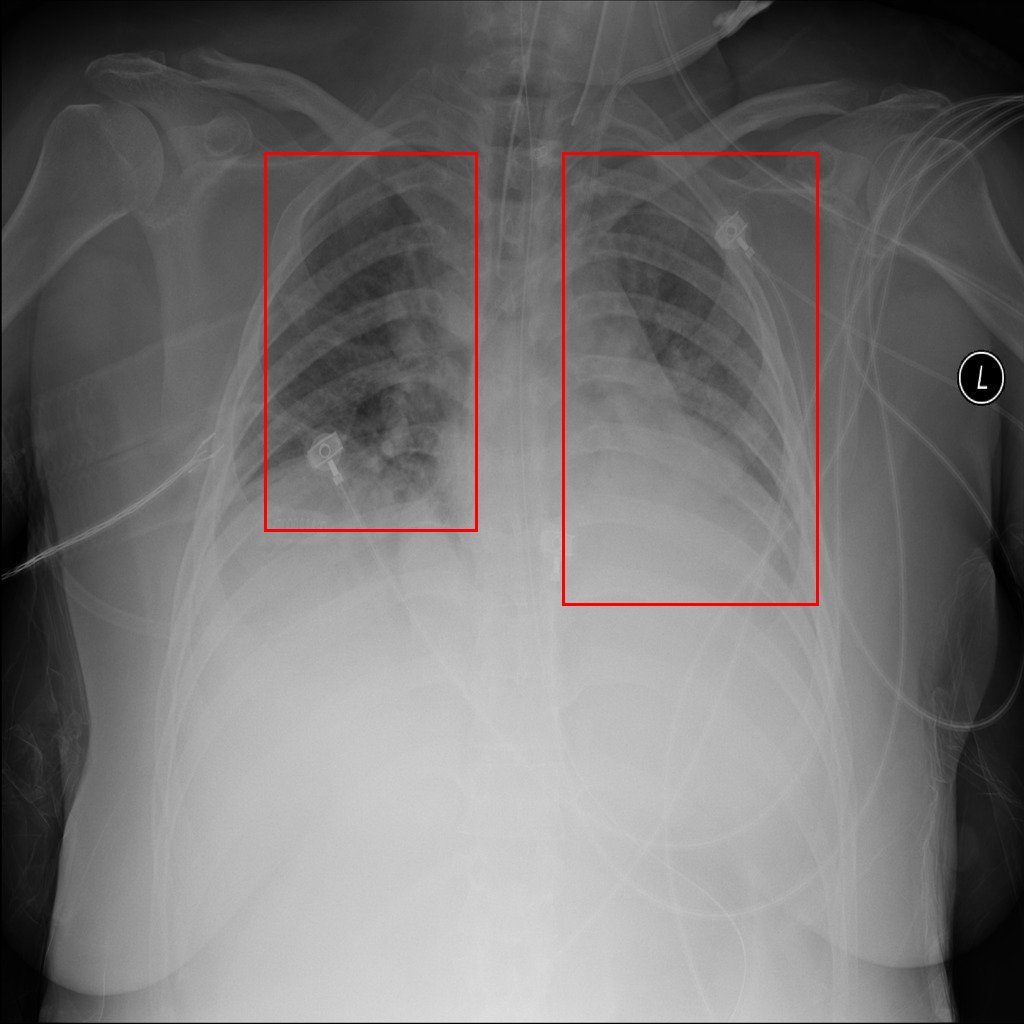

In [14]:
# CSV ファイルのパスと画像ファイルのパスを指定
csv_file = '../../datasets/rsna-pneumonia-detection-challenge/train.csv'  # 実際の CSV ファイル名に合わせてください
image_file = '../../datasets/rsna-pneumonia-detection-challenge/train_png/00436515-870c-4b36-a041-de91049b9ab4.png'

# pandas を使用して CSV ファイルを読み込む
try:
    df = pd.read_csv(csv_file)
    # 枠線を描画して表示する関数を実行
    draw_bounding_boxes_and_display(image_file, df)
except FileNotFoundError:
    print(f"エラー: CSV ファイル {csv_file} が見つかりません。")
except Exception as e:
    print(f"CSV ファイルの読み込み中にエラーが発生しました: {e}")